In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
    explained_variance_score,
)
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)
import warnings
import optuna
import logging
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")


pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


In [3]:
## config variables
import random
random.seed(42)
DIR = "../data/train/"
TARGET = "amount_new_house_transactions"
TARGET_LOG = "log_amount_new_house_transactions"
N_SPLITS   = 5 
N_TRIALS   = 50       
RANDOM_SEED = 42

In [4]:
df = pd.read_csv(f"{DIR}new_house_transactions.csv")
df['month'] = pd.to_datetime(df['month'])

nearby_df = pd.read_csv(f"{DIR}new_house_transactions_nearby_sectors.csv")
nearby_df["month"] = pd.to_datetime(nearby_df["month"])

pre_df = pd.read_csv(f"{DIR}pre_owned_house_transactions.csv")
pre_df["month"] = pd.to_datetime(pre_df["month"])


df = df.merge(nearby_df,on=["month", "sector"],how="left")
df = df.merge(pre_df,on=["month", "sector"],how="left")

df.rename(columns={"month": "date"}, inplace=True)
df['sector'] = df['sector'].str.split(' ').str[1].astype(int)
df.head()


,date,sector,num_new_house_transactions,area_new_house_transactions,price_new_house_transactions,amount_new_house_transactions,area_per_unit_new_house_transactions,total_price_per_unit_new_house_transactions,num_new_house_available_for_sale,area_new_house_available_for_sale,period_new_house_sell_through,num_new_house_transactions_nearby_sectors,area_new_house_transactions_nearby_sectors,price_new_house_transactions_nearby_sectors,amount_new_house_transactions_nearby_sectors,area_per_unit_new_house_transactions_nearby_sectors,total_price_per_unit_new_house_transactions_nearby_sectors,num_new_house_available_for_sale_nearby_sectors,area_new_house_available_for_sale_nearby_sectors,period_new_house_sell_through_nearby_sectors,area_pre_owned_house_transactions,amount_pre_owned_house_transactions,num_pre_owned_house_transactions,price_pre_owned_house_transactions
0,2019-01-01,1,52,4906,28184,13827.14,94,265.91,159.0,15904.0,3.78,29.444444,3532.444444,51992.52013,18366.06889,119.969811,623.753283,350.250000,49809.8750,29.696250,9163.0,40994.7,111.0,44739.38666
1,2019-01-01,2,145,15933,17747,28277.73,110,195.02,1491.0,175113.0,12.29,51.000000,5830.500000,18152.22108,10583.65250,114.323529,207.522598,1366.666667,170501.0000,17.093333,192.0,315.0,2.0,16406.25000
2,2019-01-01,4,6,725,28004,1424.21,127,356.05,40.0,6826.0,5.95,106.666667,10736.333330,21105.52175,22659.59167,100.653125,212.433672,2045.333333,238398.8333,29.178333,0.0,0.0,0.0,12794.68999
3,2019-01-01,5,2,212,37432,792.10,106,396.05,161.0,17173.0,83.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-01,6,5,773,15992,607.94,95,151.99,189.0,19696.0,14.27,140.888889,15084.666670,20778.66045,31343.91667,107.067823,222.472595,1613.888889,195501.5556,11.540000,388.0,993.3,4.0,25600.51546


In [5]:
df.shape

(5433, 24)

In [6]:
# =====================================================
# BUILD FULL MONTH × SECTOR GRID
# =====================================================

all_months = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="MS"
)

all_sectors = np.arange(1, 97)

full_grid = pd.MultiIndex.from_product(
    [all_months, all_sectors],
    names=["date", "sector"]
).to_frame(index=False)

df = full_grid.merge(
    df,
    on=["date", "sector"],
    how="left"
)

# Missing sector-month = 0 transactions
df = df.fillna(0)

# Recreate target after fill
df[TARGET_LOG] = np.log1p(df[TARGET])

print(df.shape)
print(
    "Expected:",
    len(all_months) * len(all_sectors)
)
print(df["date"].nunique())
print(df["sector"].nunique())
print(len(df))

(6432, 25)
Expected: 6432
67
96
6432


In [7]:
df.head()

,date,sector,num_new_house_transactions,area_new_house_transactions,price_new_house_transactions,amount_new_house_transactions,area_per_unit_new_house_transactions,total_price_per_unit_new_house_transactions,num_new_house_available_for_sale,area_new_house_available_for_sale,period_new_house_sell_through,num_new_house_transactions_nearby_sectors,area_new_house_transactions_nearby_sectors,price_new_house_transactions_nearby_sectors,amount_new_house_transactions_nearby_sectors,area_per_unit_new_house_transactions_nearby_sectors,total_price_per_unit_new_house_transactions_nearby_sectors,num_new_house_available_for_sale_nearby_sectors,area_new_house_available_for_sale_nearby_sectors,period_new_house_sell_through_nearby_sectors,area_pre_owned_house_transactions,amount_pre_owned_house_transactions,num_pre_owned_house_transactions,price_pre_owned_house_transactions,log_amount_new_house_transactions
0,2019-01-01,1,52.0,4906.0,28184.0,13827.14,94.0,265.91,159.0,15904.0,3.78,29.444444,3532.444444,51992.52013,18366.06889,119.969811,623.753283,350.250000,49809.8750,29.696250,9163.0,40994.7,111.0,44739.38666,9.534461
1,2019-01-01,2,145.0,15933.0,17747.0,28277.73,110.0,195.02,1491.0,175113.0,12.29,51.000000,5830.500000,18152.22108,10583.65250,114.323529,207.522598,1366.666667,170501.0000,17.093333,192.0,315.0,2.0,16406.25000,10.249865
2,2019-01-01,3,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.00,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.0000,0.000000,0.0,0.0,0.0,0.00000,0.000000
3,2019-01-01,4,6.0,725.0,28004.0,1424.21,127.0,356.05,40.0,6826.0,5.95,106.666667,10736.333330,21105.52175,22659.59167,100.653125,212.433672,2045.333333,238398.8333,29.178333,0.0,0.0,0.0,12794.68999,7.262074
4,2019-01-01,5,2.0,212.0,37432.0,792.10,106.0,396.05,161.0,17173.0,83.95,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.0000,0.000000,0.0,0.0,0.0,0.00000,6.675949


In [8]:
zero_rate = (df['amount_new_house_transactions'] == 0).mean()
print(f"Zero rate toàn dataset: {zero_rate:.1%}")

# Zero rate theo sector
zero_by_sector = df.groupby('sector')['amount_new_house_transactions'].apply(
    lambda x: (x == 0).mean()
).sort_values(ascending=False)
print(zero_by_sector.head(20))

# Zero có tập trung vào tháng nào không
zero_by_month = df.groupby('date')['amount_new_house_transactions'].apply(
    lambda x: (x == 0).mean()
)
print(zero_by_month)

Zero rate toàn dataset: 15.5%
sector
95    1.000000
52    0.985075
96    0.865672
87    0.820896
41    0.731343
19    0.671642
90    0.671642
49    0.671642
40    0.671642
32    0.597015
58    0.582090
3     0.552239
74    0.537313
82    0.462687
53    0.447761
5     0.447761
89    0.358209
39    0.343284
33    0.313433
78    0.313433
Name: amount_new_house_transactions, dtype: float64
date
2019-01-01    0.187500
2019-02-01    0.218750
2019-03-01    0.166667
2019-04-01    0.187500
2019-05-01    0.187500
2019-06-01    0.177083
2019-07-01    0.197917
2019-08-01    0.166667
2019-09-01    0.156250
2019-10-01    0.135417
2019-11-01    0.208333
2019-12-01    0.156250
2020-01-01    0.187500
2020-02-01    0.260417
2020-03-01    0.166667
2020-04-01    0.177083
2020-05-01    0.166667
2020-06-01    0.145833
2020-07-01    0.125000
2020-08-01    0.135417
2020-09-01    0.145833
2020-10-01    0.145833
2020-11-01    0.135417
2020-12-01    0.145833
2021-01-01    0.125000
2021-02-01    0.197917
2021-03-

### Split data into train/validation set

In [9]:
import pandas as pd

# Sắp xếp theo thời gian
df = df.sort_values(['date', 'sector']).reset_index(drop=True)

# Đảm bảo date là datetime
df['date'] = pd.to_datetime(df['date'])

# Lấy danh sách ngày duy nhất
unique_dates = sorted(df['date'].unique())

# Chọn ngày bắt đầu của tập test (20% ngày cuối)
split_idx = int(len(unique_dates) * 0.8)
split_date = unique_dates[split_idx]

# Chia train/test
train_df = df[df['date'] < split_date].copy()
test_df = df[df['date'] >= split_date].copy()

# Kiểm tra
print(f"Split date: {split_date}")

print("\nTRAIN")
print(f"Shape: {train_df.shape}")
print(f"Date range: {train_df['date'].min()} -> {train_df['date'].max()}")

print("\nTEST")
print(f"Shape: {test_df.shape}")
print(f"Date range: {test_df['date'].min()} -> {test_df['date'].max()}")

print("\nRatio:")
print(f"Train: {len(train_df)/len(df):.2%}")
print(f"Test : {len(test_df)/len(df):.2%}")

Split date: 2023-06-01 00:00:00

TRAIN
Shape: (5088, 25)
Date range: 2019-01-01 00:00:00 -> 2023-05-01 00:00:00

TEST
Shape: (1344, 25)
Date range: 2023-06-01 00:00:00 -> 2024-07-01 00:00:00

Ratio:
Train: 79.10%
Test : 20.90%


### Evaluation metric

In [10]:

def competition_score(y_true, y_pred, eps=1e-12):

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    ape = np.abs(
        y_pred - y_true
    ) / np.maximum(y_true, eps)

    # Stage 1
    bad_rate = (ape > 1.0).mean()

    if bad_rate > 0.30:
        return 0.0
    
    # Stage 2
    good_mask = ape <= 1.0

    D = ape[good_mask]

    if len(D) == 0:
        return 0.0

    mape_D = D.mean()

    good_rate = good_mask.mean()

    score = 1.0 - (mape_D / good_rate)

    return score

def evaluate_regression(y_true, y_pred, verbose=True):
    """
    Regression metrics dashboard
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    medae = median_absolute_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    evs = explained_variance_score(y_true, y_pred)

    # tránh chia cho 0
    mask = y_true > 0
    if mask.sum() > 0:
        mape = np.mean(
            np.abs(y_true[mask] - y_pred[mask])
            / y_true[mask]
        ) * 100
    else:
        mape = np.nan
    bias = np.mean(y_pred - y_true)

    metrics = {
        "rmse": rmse,
        "mae": mae,
        "mse": mse,
        "medae": medae,
        "mape": mape,
        "r2": r2,
        "Explained Variance": evs,
        "Bias": bias,
    }


    return metrics

### Run baseline : 3 baselines

1. Seasonal Naive baselines

2. Rule-based baselines

3. LightGBM baseline

In [11]:
def create_training_features_for_baseline(
    df_in,
    target_col,
    LAG_LIST=[1,2,3],
    keep_nan=True
):

    df = df_in.copy()
    df = df.sort_values(['sector', 'date']).reset_index(drop=True)

    if not np.issubdtype(df['date'].dtype, np.datetime64):
        df['date'] = pd.to_datetime(df['date'])

    
    # lag features
    for lag in LAG_LIST:
        df[f'lag_{lag}'] = (df.groupby('sector')[target_col].shift(lag))

    
    # solve nan

    if not keep_nan:

        feature_cols = [
            c for c in df.columns
            if c not in [target_col]
        ]

        df[feature_cols] = (
            df.groupby('sector')[feature_cols]
              .ffill()
        )
    df.drop([TARGET_LOG, 'num_new_house_transactions', 'area_new_house_transactions',	'price_new_house_transactions',	'area_per_unit_new_house_transactions',	'total_price_per_unit_new_house_transactions',	'num_new_house_available_for_sale',	'area_new_house_available_for_sale',	'period_new_house_sell_through'], axis = 1, inplace = True)

    return df



In [12]:
base_train = create_training_features_for_baseline(train_df, TARGET)
print('base_train shape:', base_train.shape)


base_train shape: (5088, 19)


In [13]:
def seasonal_naive_predict(history, target_date):

    match = history[
        history["date"] ==
        target_date - pd.DateOffset(years=1)
    ]

    if len(match):
        return match["amount_new_house_transactions"].iloc[0]

    recent = history.tail(12)
    if len(recent):
        return recent["amount_new_house_transactions"].mean()

    return 0


def rule_based_predict(history, horizon_date, sector):

    history = history.sort_values("date")
    target  = history["amount_new_house_transactions"]

    if sector in [52, 95]:
        return 0

    zero_rate = (target == 0).mean()
    if zero_rate > 0.7 and (target.tail(3) == 0).all():
        return 0

    match = history[history["date"] == horizon_date - pd.DateOffset(years=1)]
    if len(match):
        value = match["amount_new_house_transactions"].iloc[0]
        if value > 0:
            return value

    recent  = target.tail(6)
    nonzero = recent[recent > 0]
    if len(nonzero):
        return nonzero.mean()

    return 0


def seasonal_model(history, row):
    return seasonal_naive_predict(history, row["date"])


def rule_model(history, row):
    return rule_based_predict(history, row["date"], row["sector"])



def timeseries_cv_stat(df, predictor, n_splits=N_SPLITS):

    dates = np.sort(df['date'].unique())

    tscv = TimeSeriesSplit(
        n_splits=n_splits
    )

    all_scores = []
    all_rmse = []
    all_mae = []
    all_r2 = []
    all_mape = []

    for fold, (train_idx, val_idx) in enumerate(
        tscv.split(dates)
    ):

        train_dates = dates[train_idx]
        val_dates   = dates[val_idx]

        fold_train = df[
            df['date'].isin(train_dates)
        ]

        fold_val = df[
            df['date'].isin(val_dates)
        ]

        preds = []
        actuals = []

        for _, row in fold_val.iterrows():

            history = fold_train[
                (fold_train['sector'] == row['sector']) &
                (fold_train['date'] < row['date'])
            ]

            preds.append(
                predictor(history, row)
            )

            actuals.append(
                row[TARGET]
            )

        preds = np.array(preds)
        actuals = np.array(actuals)

        score = competition_score(
            actuals,
            preds
        )

        metrics = evaluate_regression(
            actuals,
            preds,
            verbose=False
        )

        all_scores.append(score)

        all_rmse.append(metrics["rmse"])
        all_mae.append(metrics["mae"])
        all_r2.append(metrics["r2"])
        all_mape.append(metrics["mape"])

        print(
            f"Fold {fold+1}"
            f" | Score={score:.4f}"
            f" | RMSE={metrics['rmse']:.2f}"
            f" | MAE={metrics['mae']:.2f}"
            f" | R2={metrics['r2']:.4f}"
            f" | MAPE={metrics['mape']:.2f}%"
        )

    print("\n" + "="*70)

    print(
        f"Competition Score : "
        f"{np.mean(all_scores):.4f} ± {np.std(all_scores):.4f}"
    )

    print(
        f"RMSE              : "
        f"{np.mean(all_rmse):.2f}"
    )

    print(
        f"MAE               : "
        f"{np.mean(all_mae):.2f}"
    )

    print(
        f"R²                : "
        f"{np.mean(all_r2):.4f}"
    )

    print(
        f"MAPE              : "
        f"{np.mean(all_mape):.2f}%"
    )

    print("="*70)

    return {
        "score": np.mean(all_scores),
        "rmse": np.mean(all_rmse),
        "mae": np.mean(all_mae),
        "r2": np.mean(all_r2),
        "mape": np.mean(all_mape)
    }

In [14]:
BASE_FEATURES = ['lag_1', 'lag_2', 'lag_3']

# ==========================================================
# Candidate Models
# ==========================================================

models = {

    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        iterations=500,
        depth=6,
        learning_rate=0.03,
        loss_function="MAE",
        random_seed=42,
        verbose=0
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=500,
        n_jobs=-1,
        random_state=42
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        n_jobs=-1,
        random_state=42
    ),

    "HistGB": HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_depth=6,
        max_iter=500,
        random_state=42
    )
}

# ==========================================================
# Time Series Benchmark
# ==========================================================

results = []

dates = np.sort(train_df["date"].unique())

tscv = TimeSeriesSplit(
    n_splits=N_SPLITS
)

for model_name, model in models.items():
    fold_scores = []

    fold_rmse = []
    fold_mae = []
    fold_r2 = []
    fold_mape = []
    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(
        tscv.split(dates)
    ):

        train_dates = dates[train_idx]
        val_dates = dates[val_idx]

        fold_raw_train = train_df[
            base_train["date"].isin(train_dates)
        ]

        fold_raw_val = train_df[
            base_train["date"].isin(val_dates)
        ]

        fold_combined = (
            pd.concat([
                fold_raw_train,
                fold_raw_val
            ])
            .sort_values(
                ["sector", "date"]
            )
        )

        fold_featured = create_training_features_for_baseline(
            fold_combined,
            TARGET
        )

        fold_train_feat = fold_featured[
            fold_featured["date"].isin(train_dates)
        ]

        fold_val_feat = fold_featured[
            fold_featured["date"].isin(val_dates)
        ]

        X_train = (
            fold_train_feat[BASE_FEATURES]
            .fillna(0)
        )

        y_train = (
            fold_train_feat[TARGET]
        )

        X_val = (
            fold_val_feat[BASE_FEATURES]
            .fillna(0)
        )

        y_val = (
            fold_val_feat[TARGET]
        )

        model.fit(
            X_train,
            y_train
        )

        pred = np.clip(
            model.predict(X_val),
            0,
            None
        )
        metrics = evaluate_regression(
            y_val,
            pred
        )

        fold_rmse.append(metrics["rmse"])
        fold_mae.append(metrics["mae"])
        fold_r2.append(metrics["r2"])
        fold_mape.append(metrics["mape"])
        score = competition_score(
            y_val,
            pred
        )

        fold_scores.append(score)

        print(
            f"Fold {fold+1}"
            f" | Score={score:.4f}"
            f" | RMSE={metrics['rmse']:.4f}"
            f" | MAE={metrics['mae']:.4f}"
            f" | R2={metrics['r2']:.4f}"
            f" | MAPE={metrics['mape']:.2f}%"
        )

    results.append({

        "model": model_name,

        "mean_score": np.mean(fold_scores),
        "std_score": np.std(fold_scores),

        "mean_rmse": np.mean(fold_rmse),
        "std_rmse": np.std(fold_rmse),

        "mean_mae": np.mean(fold_mae),
        "std_mae": np.std(fold_mae),

        "mean_r2": np.mean(fold_r2),
        "std_r2": np.std(fold_r2),

        "mean_mape": np.mean(fold_mape),
        "std_mape": np.std(fold_mape),
    })



LightGBM
Fold 1 | Score=0.0000 | RMSE=50127.9837 | MAE=22166.7524 | R2=0.3333 | MAPE=146.71%
Fold 2 | Score=0.0000 | RMSE=43557.6447 | MAE=24969.8314 | R2=0.5263 | MAPE=277.07%
Fold 3 | Score=0.0000 | RMSE=42378.9197 | MAE=21676.4184 | R2=0.2904 | MAPE=204.65%
Fold 4 | Score=0.0000 | RMSE=37476.2346 | MAE=16252.6829 | R2=0.2575 | MAPE=174.41%
Fold 5 | Score=0.0000 | RMSE=31932.3683 | MAE=14866.4094 | R2=0.4036 | MAPE=170.47%

XGBoost
Fold 1 | Score=0.0000 | RMSE=54061.4549 | MAE=24001.5054 | R2=0.2246 | MAPE=176.83%
Fold 2 | Score=0.0000 | RMSE=49036.0826 | MAE=26868.5949 | R2=0.3996 | MAPE=235.67%
Fold 3 | Score=0.0000 | RMSE=42372.6214 | MAE=20513.3733 | R2=0.2906 | MAPE=161.91%
Fold 4 | Score=0.0000 | RMSE=35949.8816 | MAE=15321.0024 | R2=0.3168 | MAPE=165.86%
Fold 5 | Score=0.0000 | RMSE=32994.6314 | MAE=14654.2970 | R2=0.3632 | MAPE=164.10%

CatBoost
Fold 1 | Score=0.0000 | RMSE=52013.9355 | MAE=20543.6097 | R2=0.2822 | MAPE=100.07%
Fold 2 | Score=0.0000 | RMSE=42248.0381 | MAE=2

In [15]:
print('=== TimeSeriesSplit CV  ===\n')

print('Seasonal Naive:')
timeseries_cv_stat(base_train, seasonal_model)

print('Rule-based:')
timeseries_cv_stat(base_train, rule_model)


results_df = (
    pd.DataFrame(results)
    .sort_values(
        "mean_score",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n")
print("=" * 70)
print("FINAL RANKING")
print("=" * 70)

display(results_df)

top2_models = (
    results_df["model"]
    .head(2)
    .tolist()
)

print("\nTop 2 models for tuning:")
print(top2_models)

=== TimeSeriesSplit CV  ===

Seasonal Naive:
Fold 1 | Score=0.3586 | RMSE=43260.19 | MAE=19395.66 | R2=0.3096 | MAPE=185.13%
Fold 2 | Score=0.3664 | RMSE=57421.84 | MAE=28501.02 | R2=0.2174 | MAPE=108.04%
Fold 3 | Score=0.0000 | RMSE=57106.89 | MAE=29446.96 | R2=-0.2230 | MAPE=259.49%
Fold 4 | Score=0.0000 | RMSE=49300.91 | MAE=24956.49 | R2=-0.3001 | MAPE=202.97%
Fold 5 | Score=0.3526 | RMSE=53032.07 | MAE=22698.97 | R2=-0.6451 | MAPE=212.57%

Competition Score : 0.2155 ± 0.1760
RMSE              : 52024.38
MAE               : 24999.82
R²                : -0.1282
MAPE              : 193.64%
Rule-based:
Fold 1 | Score=0.3819 | RMSE=43195.40 | MAE=19285.69 | R2=0.3116 | MAPE=186.09%
Fold 2 | Score=0.3455 | RMSE=57348.39 | MAE=28408.81 | R2=0.2194 | MAPE=133.76%
Fold 3 | Score=0.0000 | RMSE=57369.40 | MAE=29821.35 | R2=-0.2342 | MAPE=265.64%
Fold 4 | Score=0.0000 | RMSE=49279.40 | MAE=24957.88 | R2=-0.2990 | MAPE=204.74%
Fold 5 | Score=0.0000 | RMSE=50538.44 | MAE=22331.21 | R2=-0.4940 |

,model,mean_score,std_score,mean_rmse,std_rmse,mean_mae,std_mae,mean_r2,std_r2,mean_mape,std_mape
0,CatBoost,0.197783,0.242482,39437.426760,7628.717251,16758.916361,4105.519213,0.420266,0.093165,99.179852,22.981427
1,LightGBM,0.000000,0.000000,41094.630215,6105.033104,19986.418898,3810.502160,0.362206,0.095474,194.660618,45.134359
2,XGBoost,0.000000,0.000000,42882.934388,7860.365514,20271.754588,4765.574469,0.318950,0.060308,180.873397,27.875235
3,ExtraTrees,0.000000,0.000000,42017.020478,7035.565841,19929.973242,4261.014447,0.344798,0.018358,175.385143,37.131556
4,RandomForest,0.000000,0.000000,41436.466222,7060.496980,19679.933915,4231.231972,0.363178,0.031600,184.087419,36.341428
5,HistGB,0.000000,0.000000,40667.671159,7081.064584,19243.849634,4324.680951,0.383580,0.072319,181.380727,34.910447



Top 2 models for tuning:
['CatBoost', 'LightGBM']


### Error analysis

OVERALL
Competition score: 0.3525642777833802
MAE: 22698.97075520833
Bad rate (>100% error): 0.2747395833333333

TOP 15 WORST SECTORS


,mean_actual,mae,bias,mae_pct
sector,,,,
32,156748.08625,210003.45250,-97661.53500,1.339751
66,114734.82750,108155.82125,43274.62375,0.942659
85,145023.64125,94481.38125,-1255.91125,0.651490
28,116060.30750,92550.30000,50043.33750,0.797433
36,98457.11875,82986.74125,20498.30625,0.842872
55,133343.43125,72605.23375,29713.37375,0.544498
80,49656.23250,68663.31875,67815.15375,1.382773
24,47638.78125,54049.90250,28370.86750,1.134578
86,33906.58625,49832.00625,45189.67875,1.469685



MONTH ANALYSIS


,mae,bad_rate
date,,
1,22864.187187,0.343750
2,18970.690729,0.187500
3,20207.993229,0.114583
4,14526.840521,0.125000
5,21967.878958,0.208333
10,20817.643750,0.302083
11,24725.226875,0.479167
12,37511.304792,0.437500


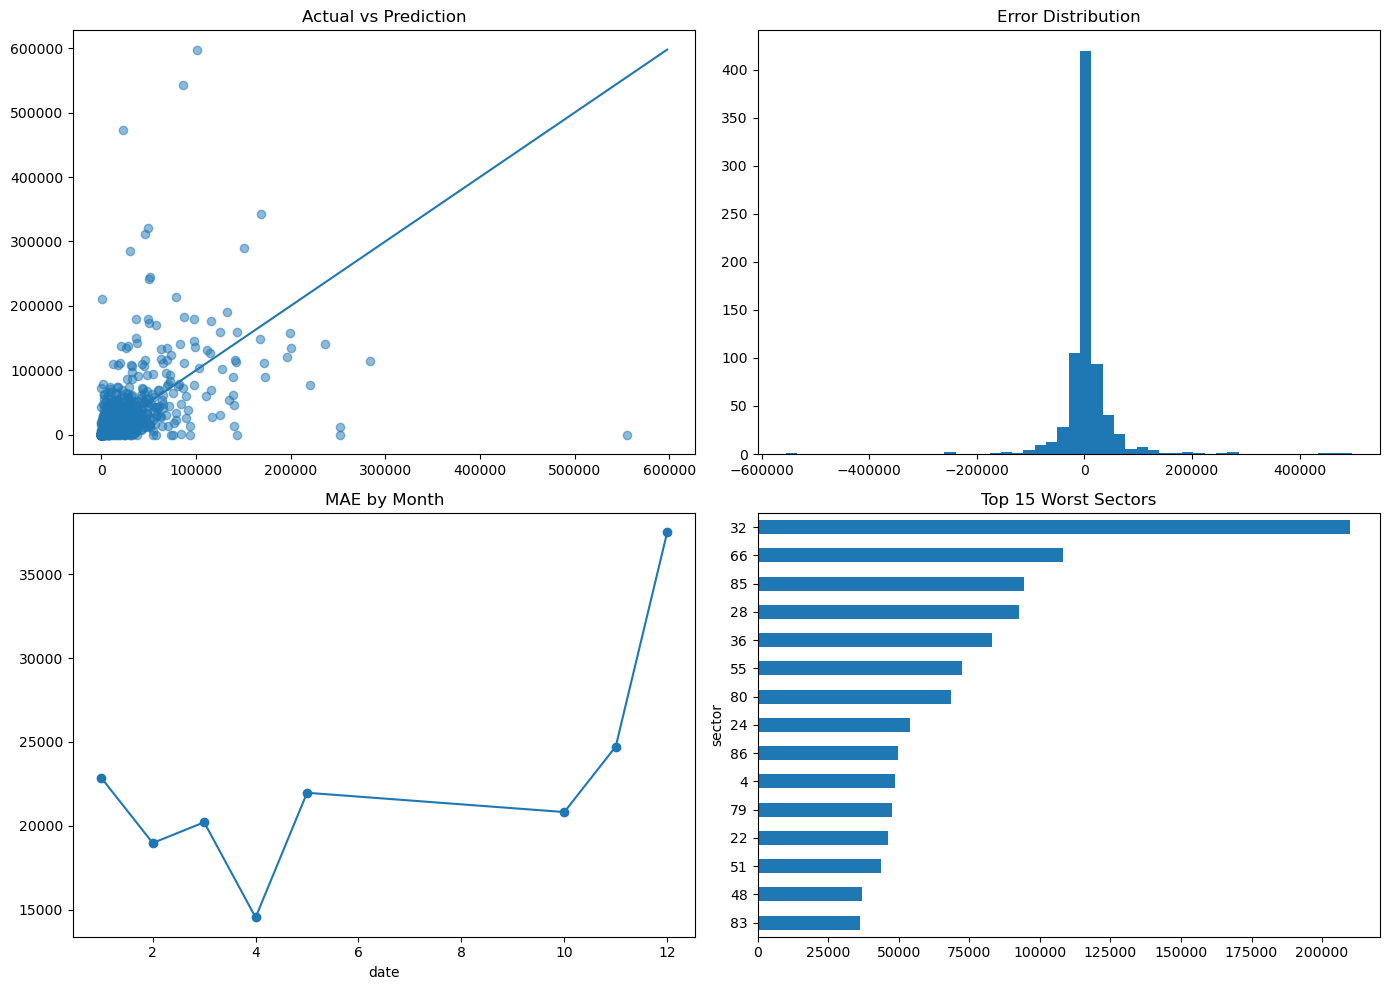

In [16]:
# LAST FOLD ANALYSIS - SEASONAL NAIVE
dates = np.sort(base_train["date"].unique())
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
splits = list(tscv.split(dates))
train_idx, val_idx = splits[-1]

train_dates = dates[train_idx]
val_dates = dates[val_idx]

fold_train = base_train[base_train["date"].isin(train_dates)]
fold_val = base_train[base_train["date"].isin(val_dates)].copy()

# SEASONAL NAIVE PREDICTION
preds = []

for _, row in fold_val.iterrows():

    target_date = row["date"] - pd.DateOffset(months=12)

    hist = fold_train[
        (fold_train["sector"] == row["sector"])
        & (fold_train["date"] == target_date)
    ]

    if len(hist):
        preds.append(hist[TARGET].iloc[0])
    else:
        preds.append(0)

fold_val["pred"] = preds

# ERROR METRICS

fold_val["error"] = fold_val["pred"] - fold_val[TARGET]
fold_val["abs_error"] = fold_val["error"].abs()

fold_val["ape"] = (
    fold_val["abs_error"]
    / np.maximum(fold_val[TARGET], 1)
)

print("=" * 60)
print("OVERALL")
print("=" * 60)

print(
    "Competition score:",
    competition_score(
        fold_val[TARGET],
        fold_val["pred"]
    )
)

print(
    "MAE:",
    fold_val["abs_error"].mean()
)

print(
    "Bad rate (>100% error):",
    (fold_val["ape"] > 1).mean()
)
# SECTOR ANALYSIS
sector_analysis = (
    fold_val
    .groupby("sector")
    .agg(
        mean_actual=(TARGET, "mean"),
        mae=("abs_error", "mean"),
        bias=("error", "mean")
    )
)

sector_analysis["mae_pct"] = (
    sector_analysis["mae"]
    / np.maximum(
        sector_analysis["mean_actual"],
        1
    )
)

print("\nTOP 15 WORST SECTORS")
display(
    sector_analysis
    .sort_values("mae", ascending=False)
    .head(15)
)

# MONTH ANALYSIS
month_analysis = (
    fold_val
    .groupby(
        fold_val["date"].dt.month
    )
    .agg(
        mae=("abs_error", "mean"),
        bad_rate=("ape", lambda x: (x > 1).mean())
    )
)

print("\nMONTH ANALYSIS")
display(month_analysis)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

# Actual vs Pred
axes[0,0].scatter(
    fold_val[TARGET],
    fold_val["pred"],
    alpha=0.5
)

max_val = max(
    fold_val[TARGET].max(),
    fold_val["pred"].max()
)

axes[0,0].plot(
    [0, max_val],
    [0, max_val]
)

axes[0,0].set_title(
    "Actual vs Prediction"
)

# Error distribution
axes[0,1].hist(
    fold_val["error"],
    bins=50
)

axes[0,1].set_title(
    "Error Distribution"
)

# Month MAE
month_analysis["mae"].plot(
    marker="o",
    ax=axes[1,0]
)

axes[1,0].set_title(
    "MAE by Month"
)

# Top sectors
(
    sector_analysis
    .sort_values("mae", ascending=False)
    .head(15)["mae"]
    .sort_values()
    .plot.barh(ax=axes[1,1])
)

axes[1,1].set_title(
    "Top 15 Worst Sectors"
)

plt.tight_layout()
plt.show()

Number of features: 3

CatBoost
Competition Score : 0.4771
R²                : 0.4866
RMSE              : 29,627
MAE               : 12,258
Bad Rate (>100%)  : 19.40%
Overestimate Rate : 52.60%
Underestimate Rate: 47.01%

MONTH ANALYSIS


,mae,bias
date,,
1,17146.900114,794.909557
2,12323.129706,-7557.804699
3,19909.510098,-19184.789293
4,7997.872526,-2095.488617
5,8624.104238,-2380.219761
10,10741.117935,1263.261303
11,8824.807407,6815.128259
12,12497.223557,-12086.671224


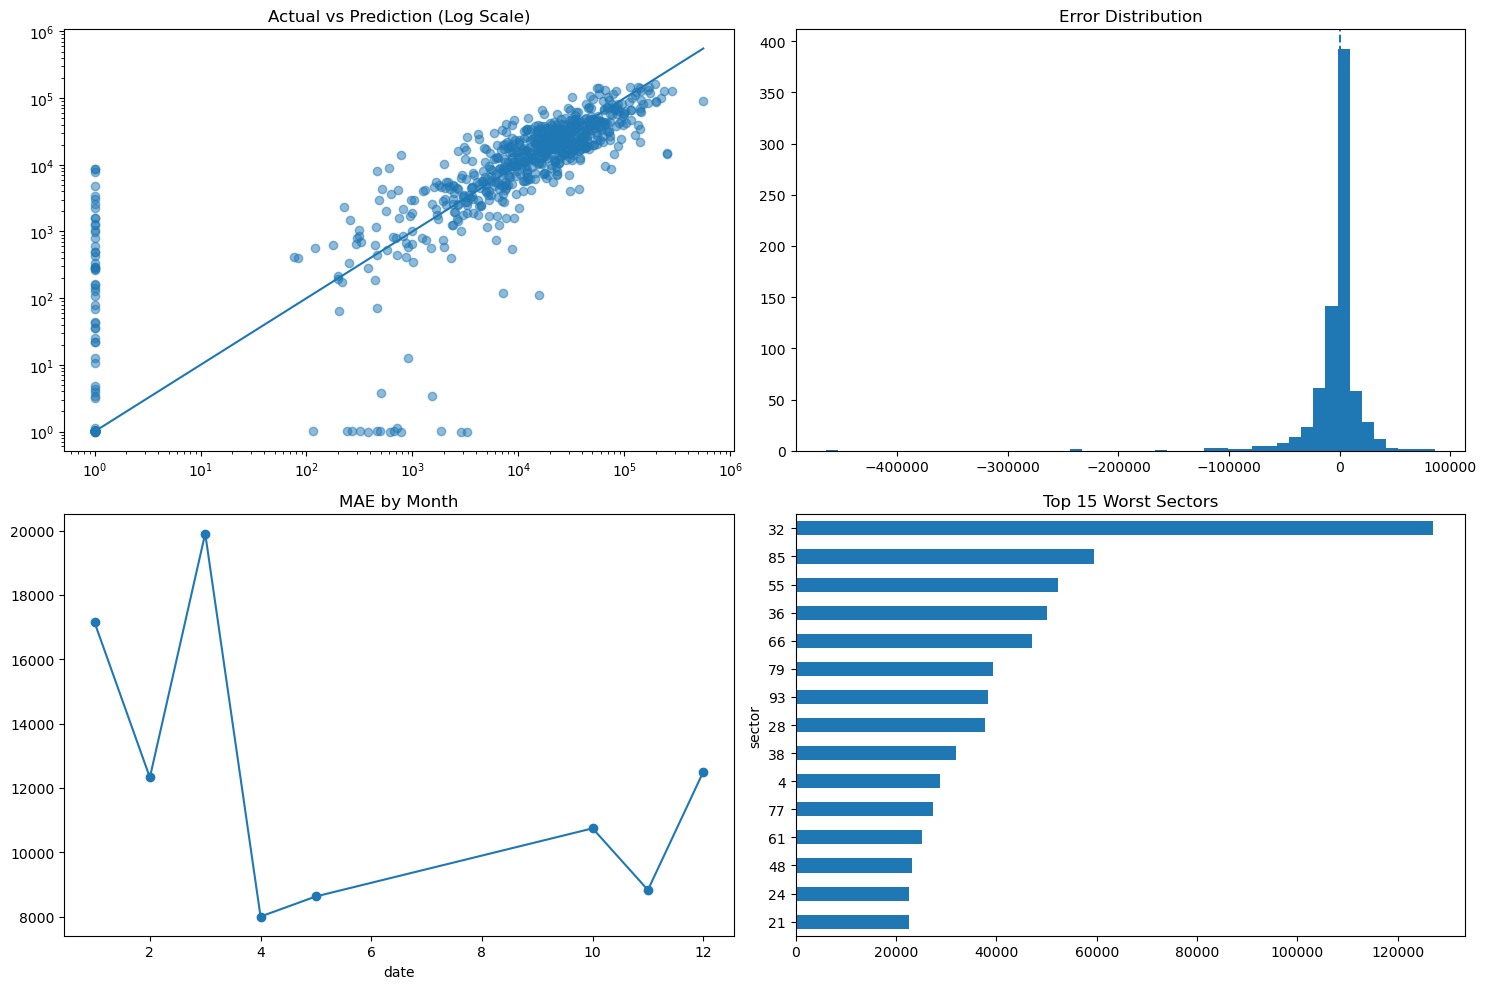

In [17]:
# ==========================================================
# LAST FOLD ANALYSIS
# ==========================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# MODEL
# ----------------------------------------------------------

MODEL_NAME = "CatBoost"

model = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.03,
    loss_function="MAE",
    random_seed=42,
    verbose=0
)

# ----------------------------------------------------------
# LAST FOLD
# ----------------------------------------------------------

dates = np.sort(train_df["date"].unique())

tscv = TimeSeriesSplit(
    n_splits=N_SPLITS
)

splits = list(tscv.split(dates))

train_idx, val_idx = splits[-1]

train_dates = dates[train_idx]
val_dates = dates[val_idx]

fold_raw_train = train_df[
    train_df["date"].isin(train_dates)
]

fold_raw_val = train_df[
    train_df["date"].isin(val_dates)
]

# ----------------------------------------------------------
# FEATURE ENGINEERING INSIDE FOLD
# ----------------------------------------------------------

fold_combined = (
    pd.concat([
        fold_raw_train,
        fold_raw_val
    ])
    .sort_values(
        ["sector", "date"]
    )
)

fold_featured = create_training_features_for_baseline(
    fold_combined,
    TARGET
)

fold_train = fold_featured[
    fold_featured["date"].isin(train_dates)
]

fold_val = fold_featured[
    fold_featured["date"].isin(val_dates)
].copy()


print(f"Number of features: {len(BASE_FEATURES)}")

# ----------------------------------------------------------
# TRAIN / VALID
# ----------------------------------------------------------

X_train = (
    fold_train[BASE_FEATURES]
    .fillna(0)
)

y_train = (
    fold_train[TARGET]
)

X_val = (
    fold_val[BASE_FEATURES]
    .fillna(0)
)

y_val = (
    fold_val[TARGET]
)

# ----------------------------------------------------------
# TRAIN MODEL
# ----------------------------------------------------------

model.fit(
    X_train,
    y_train
)

pred = np.clip(
    model.predict(X_val),
    0,
    None
)

fold_val["pred"] = pred

# ----------------------------------------------------------
# ERRORS
# ----------------------------------------------------------

fold_val["error"] = (
    fold_val["pred"]
    - fold_val[TARGET]
)

fold_val["abs_error"] = (
    fold_val["error"]
    .abs()
)

fold_val["ape"] = (
    fold_val["abs_error"]
    / np.maximum(
        fold_val[TARGET],
        1
    )
)

# ----------------------------------------------------------
# OVERALL METRICS
# ----------------------------------------------------------

print("\n" + "=" * 70)
print(MODEL_NAME)
print("=" * 70)

print(
    f"Competition Score : "
    f"{competition_score(y_val, pred):.4f}"
)

print(
    f"R²                : "
    f"{r2_score(y_val, pred):.4f}"
)

print(
    f"RMSE              : "
    f"{np.sqrt(mean_squared_error(y_val, pred)):,.0f}"
)

print(
    f"MAE               : "
    f"{mean_absolute_error(y_val, pred):,.0f}"
)

print(
    f"Bad Rate (>100%)  : "
    f"{(fold_val['ape'] > 1).mean():.2%}"
)

print(
    f"Overestimate Rate : "
    f"{(fold_val['error'] > 0).mean():.2%}"
)

print(
    f"Underestimate Rate: "
    f"{(fold_val['error'] < 0).mean():.2%}"
)

# ----------------------------------------------------------
# SECTOR ANALYSIS
# ----------------------------------------------------------

sector_analysis = (
    fold_val
    .groupby("sector")
    .agg(
        mean=(TARGET, "mean"),
        std=(TARGET, "std"),
        mae=("abs_error", "mean"),
        bias=("error", "mean")
    )
)

sector_analysis["cv"] = (
    sector_analysis["std"]
    / np.maximum(
        sector_analysis["mean"],
        1
    )
)

sector_analysis["mae_pct"] = (
    sector_analysis["mae"]
    / np.maximum(
        sector_analysis["mean"],
        1
    )
)

sector_analysis["volume"] = (
    fold_val
    .groupby("sector")[TARGET]
    .sum()
)





# ----------------------------------------------------------
# MONTH ANALYSIS
# ----------------------------------------------------------

month_analysis = (
    fold_val
    .groupby(
        fold_val["date"].dt.month
    )
    .agg(
        mae=("abs_error", "mean"),
        bias=("error", "mean")
    )
)

print("\nMONTH ANALYSIS")

display(month_analysis)



# ----------------------------------------------------------
# VISUALIZATION
# ----------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

# ==========================================================
# Actual vs Pred
# ==========================================================

axes[0,0].scatter(
    fold_val[TARGET] + 1,
    fold_val["pred"] + 1,
    alpha=0.5
)

m = max(
    fold_val[TARGET].max(),
    fold_val["pred"].max()
)

axes[0,0].plot(
    [1, m + 1],
    [1, m + 1]
)

axes[0,0].set_xscale("log")
axes[0,0].set_yscale("log")

axes[0,0].set_title(
    "Actual vs Prediction (Log Scale)"
)

# ==========================================================
# Error Distribution
# ==========================================================

axes[0,1].hist(
    fold_val["error"],
    bins=50
)

axes[0,1].axvline(
    0,
    linestyle="--"
)

axes[0,1].set_title(
    "Error Distribution"
)

# ==========================================================
# Month MAE
# ==========================================================

month_analysis["mae"].plot(
    marker="o",
    ax=axes[1,0]
)

axes[1,0].set_title(
    "MAE by Month"
)

# Top sectors
(
    sector_analysis
    .sort_values("mae", ascending=False)
    .head(15)["mae"]
    .sort_values()
    .plot.barh(ax=axes[1,1])
)

axes[1,1].set_title(
    "Top 15 Worst Sectors"
)

plt.tight_layout()
plt.show()



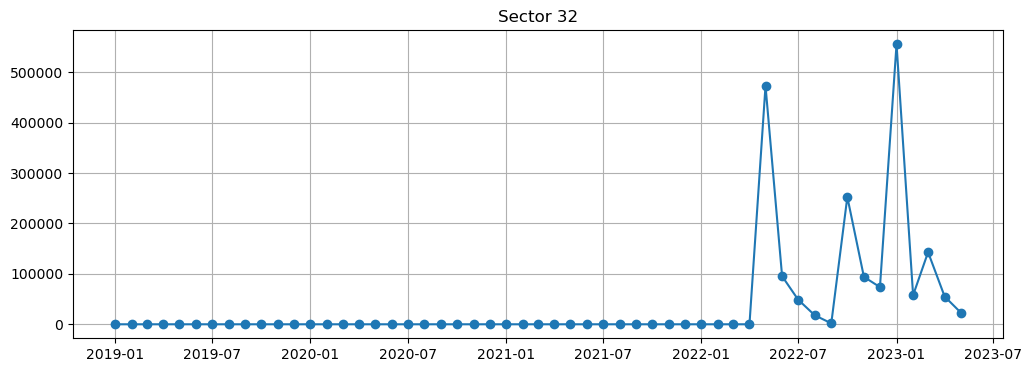

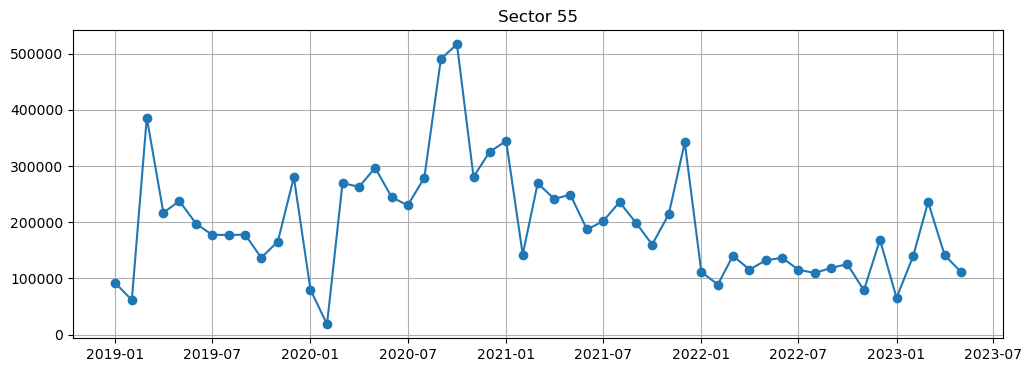

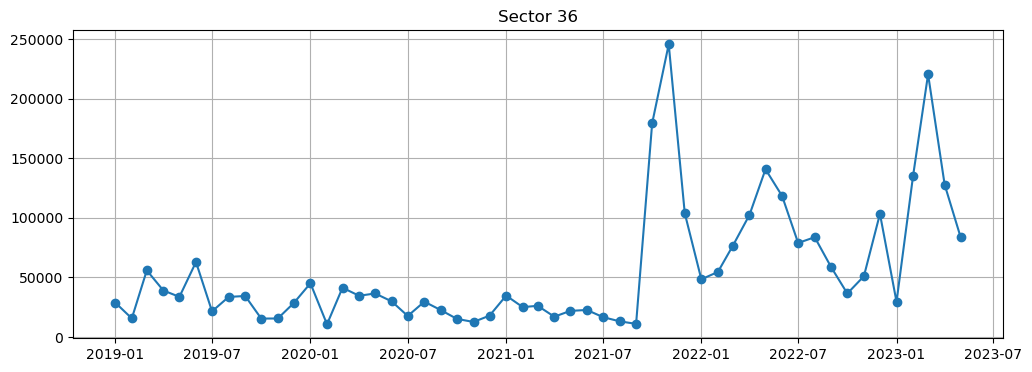

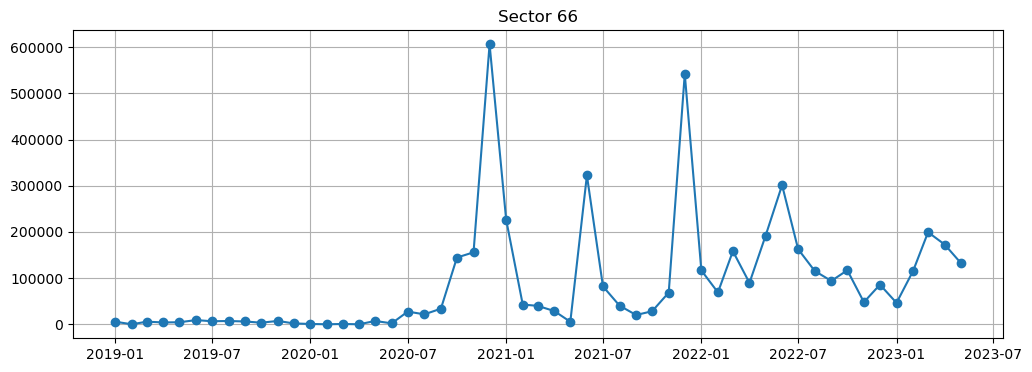

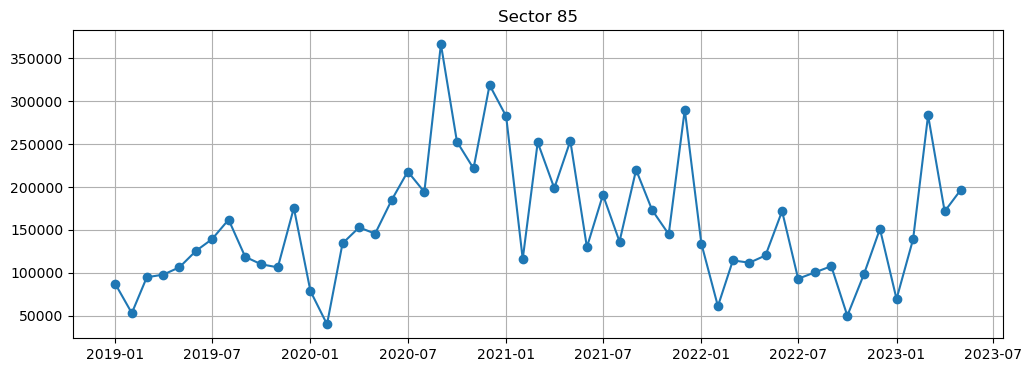

In [18]:
import matplotlib.pyplot as plt

worst_sectors = [32,55,36,66,85]

for sector in worst_sectors:

    temp = (
        base_train[base_train["sector"] == sector]
        .sort_values("date")
    )

    plt.figure(figsize=(12,4))

    plt.plot(
        temp["date"],
        temp[TARGET],
        marker="o"
    )

    plt.title(f"Sector {sector}")
    plt.grid(True)

    plt.show()

# Error Analysis: Seasonal Naive vs CatBoost Baselines

## Overview

Two baseline models were evaluated using a time-based validation split:

### 1. Seasonal Naive

Forecasts each observation using the value from the same month in the previous year.

$$
\hat y_t = y_{t-12}
$$

This model assumes that transaction volume follows a repeating annual seasonal pattern.

### 2. CatBoost Baseline

Uses short-term autoregressive features:

- `lag_1`
- `lag_2`
- `lag_3`

CatBoost can learn non-linear relationships between recent observations and generally provides greater flexibility than a simple seasonal baseline.

The objective of this analysis is not only to compare model performance but also to understand the underlying causes of forecasting errors and identify the dominant challenges of the competition.

---

# 1. Error Concentration Remains Similar Across Models

Despite the improvement in overall accuracy, CatBoost and Seasonal Naive continue to struggle on many of the same sectors.

Recurring high-error sectors include:

- Sector 32
- Sector 55
- Sector 36
- Sector 66
- Sector 85

These sectors consistently appear among the worst-performing groups regardless of model choice.

## Key Observation

The persistence of these sectors across different forecasting approaches suggests that the dominant source of error is not algorithm-specific.

Instead, these sectors appear intrinsically difficult to forecast due to:

- high volatility,
- structural regime changes,
- long-term trend shifts,
- abrupt demand surges.

This indicates that future gains are more likely to come from feature engineering and sector-specific modeling than from simply replacing one machine learning algorithm with another.

---

# 2. Large Sectors Dominate Overall Forecasting Error

The sectors contributing the largest MAE are generally those with substantial transaction volume.

Examples include:

| Sector | Characteristics |
|----------|----------|
| 55 | Very large transaction volume |
| 66 | High volume and high volatility |
| 85 | Large transaction volume |
| 36 | Medium-high transaction volume |

Although sparse sectors are difficult to forecast, their contribution to total competition error is relatively small.

## Implication

Improving forecasts on large sectors is likely to generate significantly larger leaderboard gains than focusing exclusively on sparse sectors.

Therefore:

- sparse sectors should still receive rule-based handling,
- but most model-development effort should target high-volume sectors.

---

# 3. CatBoost Still Underpredicts Extreme Demand

The Actual vs Prediction plots reveal a characteristic pattern.

For normal transaction levels:

- predictions closely follow the diagonal,
- forecasting accuracy is relatively strong.

For very large transaction values:

- predictions increasingly fall below actual observations,
- large spikes remain underestimated.

## Evidence

Many observations lie below the ideal prediction line:

$$
Prediction < Actual
$$

This suggests that CatBoost still shrinks extreme values toward the historical average.

Although the model performs substantially better than Seasonal Naive, it does not fully solve the problem of forecasting sudden transaction surges.

---

# 4. The Main Failure Modes Extend Beyond Simple Demand Spikes

Inspection of the worst-performing sectors reveals several distinct behaviors.

## Structural Breaks

Some sectors remain nearly inactive for several years before suddenly entering a high-activity regime.

### Example: Sector 32

```text
2019-2021 : near-zero activity
2022+     : persistent high transaction volume
```

This represents a structural regime shift rather than a seasonal pattern.

Because historical observations contain little information about the future regime transition, both Seasonal Naive and CatBoost struggle to adapt quickly.

---

## Long-Term Trend Changes

Certain sectors exhibit clear upward or downward market trends.

### Example: Sector 55

```text
2019-2021 : very strong demand
2022-2024 : gradual decline
```

In these cases:

- short lags only capture local dynamics,
- yearly seasonality becomes less informative,
- long-term market evolution becomes the dominant driver.

---

## Demand Spikes

Several sectors contain isolated transaction surges.

### Example

```text
20k
25k
18k
210k   ← spike
30k
22k
```

These spikes often exceed normal transaction levels by several multiples.

Because neither Seasonal Naive nor CatBoost receives information indicating that a spike is imminent, both models naturally predict values closer to recent historical averages.

As a result:

- normal periods are forecast accurately,
- spike periods generate disproportionately large errors.

---

## Observation

The largest forecasting errors do not originate from a single source.

Instead, difficult sectors are characterized by a combination of:

- structural regime changes,
- long-term trend shifts,
- demand spikes,
- elevated volatility.

This explains why replacing Seasonal Naive with CatBoost improves overall accuracy but does not eliminate the major error sectors.

---

# 5. Limited Evidence of Strong Annual Seasonality

One surprising finding is that Seasonal Naive remains reasonably competitive despite its simplicity.

However, visual inspection of the worst-performing sectors reveals limited evidence of strong repeating yearly patterns.

Sectors such as:

- 32
- 36
- 55
- 66

appear to be driven more by:

- market cycles,
- regime transitions,
- local trends,

than by stable annual seasonality.

This suggests that future improvements may come more from capturing market regimes and sector evolution than from adding increasingly long seasonal lags.

---

# 6. Monthly Error Patterns Suggest Calendar Effects

Monthly MAE is not uniform throughout the year.

Several months exhibit noticeably larger forecasting errors than others.

This suggests that:

- transaction activity is influenced by seasonal market behavior,
- certain months experience stronger demand fluctuations,
- annual seasonality exists but is not fully captured by simple lag features.

The presence of month-specific error patterns supports the inclusion of:

- month indicators,
- cyclical month encoding (`sin/cos`),
- regime-specific seasonal effects.

---

# 7. What The Baselines Tell Us

## What Works

- Recent transaction history contains meaningful predictive information.
- Machine learning models outperform purely seasonal forecasting.
- CatBoost significantly reduces forecasting error relative to Seasonal Naive.

## What Does Not Work

- Structural regime changes remain difficult to forecast.
- Extreme transaction spikes are consistently underestimated.
- Large sectors dominate leaderboard performance.
- Algorithm changes alone do not solve the primary forecasting challenges.

## Implications for Model Design

The next model iteration should focus on:

1. Rule-based handling of near-zero sectors.
2. Trend-aware features.
3. Regime-aware features.
4. Rolling demand statistics.
5. Sector-level profiling.
6. Volatility-aware forecasting.
7. Spike-sensitive modeling.

## Expected Sources of Future Gains

The evidence suggests that the largest performance improvements are more likely to come from:

- better time-series feature engineering,
- sector segmentation,
- regime modeling,

rather than switching from one tree-based algorithm to another.


### Design model 

#### Feature engineer

In [19]:
DROP_COLS = ['num_new_house_transactions',
       'area_new_house_transactions', 'price_new_house_transactions',
       'amount_new_house_transactions', 'area_per_unit_new_house_transactions',
       'total_price_per_unit_new_house_transactions',
       'num_new_house_available_for_sale', 'area_new_house_available_for_sale',
       'period_new_house_sell_through', 'transportation_station_dense',
       'education_dense', 'medical_health_dense',
       'num_new_house_transactions_nearby_sectors',
       'area_new_house_transactions_nearby_sectors',
       'price_new_house_transactions_nearby_sectors',
       'amount_new_house_transactions_nearby_sectors',
       'area_per_unit_new_house_transactions_nearby_sectors',
       'total_price_per_unit_new_house_transactions_nearby_sectors',
       'num_new_house_available_for_sale_nearby_sectors',
       'area_new_house_available_for_sale_nearby_sectors',
       'period_new_house_sell_through_nearby_sectors',
       'area_pre_owned_house_transactions',
       'amount_pre_owned_house_transactions',
       'num_pre_owned_house_transactions',
       'price_pre_owned_house_transactions']

def assign_regime(month):
    if month < pd.Timestamp("2020-01-01"):
        return 0
    elif month < pd.Timestamp("2020-07-01"):
        return 1
    elif month < pd.Timestamp("2022-01-01"):
        return 2
    else:
        return 3
def create_training_features(
    df_in,
    target_col,
    sector_stats=None, sector_profile=None,
    LAG_LIST=[1,2,3,6,12],
    rolling_windows=[3,6,12],
    keep_nan=True,
):

    df = df_in.copy()
    df = (df.sort_values(["sector","date"]).reset_index(drop=True))

    if not np.issubdtype(df["date"].dtype, np.datetime64):
        df["date"] = pd.to_datetime(df["date"])

    # Calendar
    df["month"] = df["date"].dt.month
    df["quarter"] = df["date"].dt.quarter
    df["year"] = df["date"].dt.year

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # Regime
    if "regime" not in df.columns:
        df["regime"] = (df["date"].apply(assign_regime))

    # Trend
    df["trend"] = (df.groupby("sector").cumcount())

    df["trend_months"] = ((df["date"]- df.groupby("sector")["date"].transform("min")).dt.days / 30.0)

    # Lags
    for lag in LAG_LIST:
        df[f"lag_{lag}"] = (df.groupby("sector")[target_col].shift(lag))

    shifted_target = (df.groupby("sector")[target_col].shift(1))

    lag13 = (df.groupby("sector")[target_col].shift(13))

    # Momentum
    df["momentum_1"]     = df["lag_1"] - df.groupby("sector")[target_col].shift(2)
    df["momentum_3"]     = df["lag_1"] - df.groupby("sector")[target_col].shift(4)
    df["momentum_pct_1"] = (df["lag_1"] - df.groupby("sector")[target_col].shift(2)) / (
        df.groupby("sector")[target_col].shift(2).abs() + 1e-9
    )
    # Rolling
    for w in rolling_windows:
        df[f"rolling_mean_{w}"] = (shifted_target.groupby(df["sector"]).transform(lambda x:x.rolling(w,min_periods=1).mean()))
        df[f"rolling_std_{w}"] = (shifted_target.groupby(df["sector"]).transform(lambda x:x.rolling(w,min_periods=2).std()))

    # Volatility
    df["vol_ratio_3_12"] = (df["rolling_std_3"]/(df["rolling_std_12"]+ 1e-9))

    # Expanding
    df["expanding_mean"] = (shifted_target.groupby(df["sector"]).transform(lambda x:x.expanding().mean()))

    # Trend strength
    df["trend_strength"] = (df["rolling_mean_3"]/(df["rolling_mean_12"]+ 1))

    # Zero rate
    shifted_zero = shifted_target.eq(0)
    for w in [6,12]:
        df[f"zero_rate_{w}"] = (shifted_zero.groupby(df["sector"]).transform(lambda x:x.rolling(w,min_periods=1).mean()))

    # YoY
    df["yoy_diff"] = (df["lag_1"]- lag13)
    df["yoy_ratio"] = (df["lag_1"]/(lag13+ 1))

    # Rolling max/min
    df["rolling_max_12"] = (shifted_target.groupby(df["sector"]).transform(lambda x:x.rolling(12,min_periods=1).max()))
    df["rolling_min_12"] = (shifted_target.groupby(df["sector"]).transform(lambda x:x.rolling(12,min_periods=1).min()))

    df["spike_ratio"] = ( df["rolling_max_12"]/(df["rolling_mean_12"]+ 1))
    df["volatility_ratio"] = (df["rolling_std_12"]/(df["rolling_mean_12"]+ 1))
    df["regime_trend"] = (df["regime"]* df["trend"])
    df["regime_month_sin"] = (df["regime"]* df["month_sin"])
    df["regime_month_cos"] = (df["regime"]* df["month_cos"])

    if sector_profile is not None:
        df["sector_type"] = (df["sector"].map(sector_profile).fillna("normal"))
    else:
        df["sector_type"] = "normal"

    type_map = {
    "dead":0,
    "normal":1,
    "spike":2}

    df["sector_type"] = (df["sector_type"].map(type_map))
    
    df["downtrend_signal"] = (df["rolling_mean_3"] < df["rolling_mean_12"] * 0.5).astype(int)

    # Train-fold sector stats
    if sector_stats is not None:
        df["sector_mean_train"] = (df["sector"].map(sector_stats["mean"]))
        df["sector_std_train"] = (df["sector"].map(sector_stats["std"]))
        df["sector_zero_rate_train"] = (df["sector"].map(sector_stats["zero_rate"]))
        df["sector_cv_train"] = (df["sector"].map(sector_stats["cv"]))

    # exogenous features
    df["nearby_supply_lag1"] = (df.groupby("sector")["num_new_house_available_for_sale_nearby_sectors"].shift(1))
    df["nearby_sellthrough_lag1"] = (df.groupby("sector")["period_new_house_sell_through_nearby_sectors"].shift(1))

    g = df.groupby("sector")
    df["sellthrough_lag1"] = (g["period_new_house_sell_through"].shift(1))
    df["nearby_price_lag1"] = (g["price_new_house_transactions_nearby_sectors"].shift(1))
    df["preowned_area_lag1"] = (g["area_pre_owned_house_transactions"].shift(1))

    # Fill NA
    if not keep_nan:

        feature_cols = [
            c
            for c in df.columns
            if c != target_col
        ]

        df[feature_cols] = (
            df.groupby("sector")[feature_cols]
            .ffill()
        )

    # ==================================================
    # Drop raw columns
    # ==================================================

    drop_cols = [
        c
        for c in DROP_COLS
        if c in df.columns
    ]

    df.drop(
        columns=drop_cols,
        inplace=True
    )

    return df

In [ ]:

# Features built inside create_training_features
FEATURES = [
    "downtrend_signal",
    # Calendar
    "month",
    "quarter",
    "year",
    "month_sin",
    "month_cos",

    # Regime
    "regime",

    # Trend
    "trend",
    "trend_months",

    # Lags
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",

    # Momentum
    "momentum_1",
    "momentum_3",
    "momentum_pct_1",

    # Rolling statistics
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_12",
    "rolling_std_3",
    "rolling_std_6",
    "rolling_std_12",

    # Volatility / Trend
    "vol_ratio_3_12",
    "expanding_mean",
    "trend_strength",

    # Zero rate
    "zero_rate_6",
    "zero_rate_12",

    # YoY
    "yoy_diff",
    "yoy_ratio",

    # Rolling extremes
    "rolling_max_12",
    "rolling_min_12",

    # Spike / Volatility
    "spike_ratio",
    "volatility_ratio",

    # Interactions
    "regime_trend",
    "regime_month_sin",
    "regime_month_cos",

    # Sector profile
    "sector_type",

    # Exogenous
    "nearby_supply_lag1",
    "nearby_sellthrough_lag1",

    # Train-fold sector stats (optional)
    "sector_mean_train",
    "sector_std_train",
    "sector_zero_rate_train",
    "sector_cv_train",
    # exogeneous
    "sellthrough_lag1",
    "nearby_price_lag1",
    "preowned_area_lag1"
]

def build_sector_profile(df_train_fold):

    profile = (
        df_train_fold
        .groupby("sector")[TARGET_LOG]
        .agg(["mean", "std"])
        .reset_index()
    )

    profile["cv"] = profile["std"] / (profile["mean"] + 1)

    profile["zero_rate"] = (
        df_train_fold
        .groupby("sector")[TARGET_LOG]
        .apply(lambda x: (x == 0).mean())
        .values
    )

    profile["sector_type"] = "normal"

    profile.loc[
        profile["zero_rate"] >= 0.85,
        "sector_type"
    ] = "dead"

    profile.loc[
        (profile["zero_rate"] < 0.85)
        &
        (profile["cv"] >= 1.20),
        "sector_type"
    ] = "spike"

    return dict(
        zip(
            profile["sector"],
            profile["sector_type"]
        )
    )

def build_zero_sector_mask(df_train, zero_thresh=0.85, recent_n=6):
    """
    Identify sectors that should always be predicted as 0.

    Rules (any one triggers → predict 0):
      A) Historical zero-rate >= zero_thresh  (e.g. 85% of months = 0)
      B) Last `recent_n` months are ALL zero  (recently dormant)
      C) Hardcoded dead sectors (52, 95 from EDA)

    Returns
    -------
    zero_sectors : set of int
    sector_meta  : DataFrame with diagnostics per sector
    """
    hardcoded = {52, 95, 49, 74}

    sector_meta = (
        df_train.groupby("sector")[TARGET_LOG]
        .agg(
            total_obs   = "count",
            zero_count  = lambda x: (x == 0).sum(),
            mean_val    = "mean",
            last_mean   = lambda x: x.iloc[-recent_n:].mean() if len(x) >= recent_n else x.mean(),
            last_zeros  = lambda x: (x.iloc[-recent_n:] == 0).all() if len(x) >= recent_n else (x == 0).all(),
        )
        .reset_index()
    )

    sector_meta["zero_rate"]  = sector_meta["zero_count"] / sector_meta["total_obs"]
    sector_meta["rule_A"]     = sector_meta["zero_rate"] >= zero_thresh
    sector_meta["rule_B"]     = sector_meta["last_zeros"]
    sector_meta["rule_hard"]  = sector_meta["sector"].isin(hardcoded)
    sector_meta["is_zero_sector"] = (
        sector_meta["rule_A"] | sector_meta["rule_B"] | sector_meta["rule_hard"]
    )

    zero_sectors = set(
        sector_meta.loc[sector_meta["is_zero_sector"], "sector"].tolist()
    )

    n = len(zero_sectors)
    print(f"[Zero-Sector Rule] {n} sectors flagged as always-zero → predict 0")
    print(f"  Rule A (zero_rate >= {zero_thresh:.0%}): "
          f"{sector_meta['rule_A'].sum()} sectors")
    print(f"  Rule B (last {recent_n} months all zero): "
          f"{sector_meta['rule_B'].sum()} sectors")
    print(f"  Rule Hard (sector 52, 95, 49, 74): {sector_meta['rule_hard'].sum()} sectors")

    return zero_sectors, sector_meta


def apply_zero_sector_rule(predictions: np.ndarray,
                           sectors: pd.Series,
                           zero_sectors: set) -> np.ndarray:
    """Zero-out predictions for flagged sectors."""
    preds = predictions.copy()
    mask  = sectors.isin(zero_sectors).values
    preds[mask] = 0.0
    return preds


def compute_sector_stats(df_train_fold, target_col):
    """
    Compute per-sector statistics from the training fold ONLY.
    Pass the result to create_training_features() as sector_stats.
    """
    stats = df_train_fold.groupby("sector")[target_col].agg(["mean", "std"])
    stats["zero_rate"] = df_train_fold.groupby("sector")[target_col].apply(
        lambda x: (x == 0).mean()
    )
    stats["cv"] = stats["std"] / (stats["mean"] + 1e-9)
    return {
        "mean":      stats["mean"].to_dict(),
        "std":       stats["std"].to_dict(),
        "zero_rate": stats["zero_rate"].to_dict(),
        "cv":        stats["cv"].to_dict(),
    }


# ==============================================================
# 4. STANDARD TIMESERIES CV  (fold-correct feature engineering)
# ==============================================================

def get_valid_features(df):
    """Return only FEATURES columns that actually exist in df."""
    return [f for f in FEATURES if f in df.columns]


def timeseries_cv(
    df_all,
    model,
    n_splits=N_SPLITS,
    zero_sectors=None,
    verbose=True,
):
    """
    Proper TimeSeriesSplit CV:
      - Feature engineering computed INSIDE each fold
      - sector_stats computed from train fold only (no leakage)
      - Zero-sector rule applied after prediction

    Returns
    -------
    fold_scores : list of competition scores
    oof_df      : DataFrame with columns [date, sector, actual, pred, fold]
    """
    fold_metrics = []
    dates  = np.sort(df_all["date"].unique())
    tscv   = TimeSeriesSplit(n_splits=n_splits)
    fold_scores = []
    oof_parts   = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(dates)):
        train_dates = dates[train_idx]
        val_dates   = dates[val_idx]

        raw_train = df_all[df_all["date"].isin(train_dates)]
        raw_val   = df_all[df_all["date"].isin(val_dates)]

        # --- Sector stats from train only ---
        sector_stats = compute_sector_stats(raw_train, TARGET_LOG)
        sector_profile = build_sector_profile(raw_train)
        # --- Feature engineering (combine, compute, then split back) ---
        combined = (
            pd.concat([raw_train, raw_val])
            .sort_values(["sector", "date"])
        )
        featured = create_training_features(
            combined,
            TARGET_LOG,
            sector_stats=sector_stats,
            sector_profile=sector_profile,
            keep_nan=False,
        )
        fold_train = featured[featured["date"].isin(train_dates)]
        fold_val   = featured[featured["date"].isin(val_dates)].copy()

        feats = get_valid_features(featured)

        X_train = fold_train[feats].fillna(0)
        y_train = fold_train[TARGET_LOG]
        X_val   = fold_val[feats].fillna(0)
        y_val   = fold_val[TARGET_LOG]

        model.fit(X_train, y_train)
        pred = np.clip(model.predict(X_val), 0, None)

        # --- Apply zero-sector rule ---
        if zero_sectors:
            pred = apply_zero_sector_rule(pred, fold_val["sector"], zero_sectors)
        
        pred_real = np.expm1(pred)
        y_real = np.expm1(y_val)
        metrics = evaluate_regression(
            y_real,
            pred_real
        )

        score = competition_score(
            y_real,
            pred_real
        )

        fold_scores.append(score)

        oof_part = fold_val[["date", "sector", TARGET_LOG]].copy()
        oof_part["pred"] = pred
        oof_part["fold"] = fold + 1
        oof_parts.append(oof_part)


        metrics["CompetitionScore"] = score
        metrics["Fold"] = fold + 1

        fold_metrics.append(metrics)
    oof_df = pd.concat(oof_parts).reset_index(drop=True)
    metrics_df = pd.DataFrame(fold_metrics)
    if verbose:

        display_df = metrics_df[
            [
                "Fold",
                "CompetitionScore",
                "mae",
                "rmse",
                "r2",
                "mape",
            ]
        ].copy()

        mean_row = {
            "Fold": "MEAN",
            "CompetitionScore": display_df["CompetitionScore"].mean(),
            "mae": display_df["mae"].mean(),
            "rmse": display_df["rmse"].mean(),
            "r2": display_df["r2"].mean(),
            "mape": display_df["mape"].mean(),
        }

        std_row = {
            "Fold": "STD",
            "CompetitionScore": display_df["CompetitionScore"].std(),
            "mae": display_df["mae"].std(),
            "rmse": display_df["rmse"].std(),
            "r2": display_df["r2"].std(),
            "mape": display_df["mape"].std(),
        }

        summary_df = pd.concat(
            [
                display_df,
                pd.DataFrame([mean_row, std_row])
            ],
            ignore_index=True
        )

        print("\nFold Metrics")
        print("=" * 80)

        print(
            summary_df.to_string(
                index=False,
                float_format=lambda x: f"{x:.4f}"
            )
        )

        print("=" * 80)
    return fold_scores, oof_df


# ==============================================================
# 5. CATBOOST TUNED
def build_catboost(params=None):
    default = {
        "iterations":        500,
        "depth":             6,
        "learning_rate":     0.05,
        "l2_leaf_reg":       3.0,
        "random_strength":   1.0,
        "border_count":      128,
        "bootstrap_type":    "Bayesian",
        "bagging_temperature": 1.0,   # ← chỉ giữ trong default vì default là Bayesian
        "verbose":           0,
        "random_seed":       RANDOM_SEED,
        "loss_function":     "MAE",
    }

    if params:
        # Nếu params truyền vào là Bernoulli thì phải xóa bagging_temperature
        merged = {**default, **params}
        if merged.get("bootstrap_type") == "Bernoulli":
            merged.pop("bagging_temperature", None)
        return CatBoostRegressor(**merged)
    
    return CatBoostRegressor(**default)

def catboost_objective(trial, df_all, zero_sectors, n_splits=N_SPLITS):

    bootstrap_type = trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli"])

    params = {
        "iterations":        trial.suggest_int("iterations", 1500, 5000),
        "depth":             trial.suggest_int("depth", 4, 7),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        "l2_leaf_reg":       trial.suggest_float("l2_leaf_reg", 1, 30.0, log=True),
        "random_strength":   trial.suggest_float("random_strength", 0.5, 5.0, log=True),
        "min_data_in_leaf":  trial.suggest_int("min_data_in_leaf", 15, 80),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 0.9),
        "border_count":      trial.suggest_categorical("border_count", [128, 254]),
        "leaf_estimation_iterations": trial.suggest_int("leaf_estimation_iterations", 3, 10),
        "bootstrap_type":    bootstrap_type,
    }

    if bootstrap_type == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0.0, 3.0)
    else:  # Bernoulli
        params["subsample"] = trial.suggest_float("subsample", 0.5, 1.0)

    model = build_catboost(params)
    scores, _ = timeseries_cv(df_all, model, n_splits=n_splits,
                            zero_sectors=zero_sectors, verbose=False)
    return np.mean(scores)


# ==============================================================
# 6. LIGHTGBM TUNED
# ==============================================================

def build_lgbm(params=None):
    defaults = dict(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=63,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        n_jobs=-1,
        random_state=RANDOM_SEED,
        verbosity=-1,
    )
    if params:
        defaults.update(params)
    return LGBMRegressor(**defaults)


def lgbm_objective(trial, df_all, zero_sectors, n_splits=N_SPLITS):
    """Optuna objective for LightGBM — wider search space."""

    params = {
        # Capacity
        "n_estimators":      trial.suggest_int("n_estimators", 1500, 5000),
        "num_leaves":        trial.suggest_int("num_leaves", 31, 255),
        "max_depth":         trial.suggest_int("max_depth", 4, 9),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.05, log=True),

        # Regularization
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "min_child_weight":  trial.suggest_float("min_child_weight", 0.01, 5.0, log=True),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1, 20.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1, 20.0, log=True),
        "min_split_gain":    trial.suggest_float("min_split_gain", 0.0, 1.0),

        # Sampling
        "subsample":         trial.suggest_float("subsample", 0.6, 0.9),
        "subsample_freq":    trial.suggest_int("subsample_freq", 1, 10),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "colsample_bynode":  trial.suggest_float("colsample_bynode", 0.5, 1.0),

        # Tree structure
        "extra_trees":       trial.suggest_categorical("extra_trees", [True, False]),
        "path_smooth":       trial.suggest_float("path_smooth", 0.0, 10.0),
    }

    model = build_lgbm(params)
    scores, _ = timeseries_cv(df_all, model, n_splits=n_splits,
                              zero_sectors=zero_sectors, verbose=False)
    return np.mean(scores)

# ==============================================================
# 7. OPTUNA TUNING
# ==============================================================

def tune_model(model_name, df_all, zero_sectors, n_trials=N_TRIALS, n_splits=N_SPLITS):
    """
    Run Optuna hyperparameter search for a given model.

    Returns
    -------
    best_params : dict
    study       : optuna.Study
    """
    assert model_name in ("catboost", "lgbm"), "model_name must be 'catboost' or 'lgbm'"

    print(f"\n{'='*60}")
    print(f"Optuna tuning: {model_name.upper()} | {n_trials} trials | {n_splits}-fold CV")
    print(f"{'='*60}")

    if model_name == "catboost":
        objective = lambda trial: catboost_objective(trial, df_all, zero_sectors, n_splits)
    else:
        objective = lambda trial: lgbm_objective(trial, df_all, zero_sectors, n_splits)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f"\n  Best score : {study.best_value:.4f}")
    print(f"  Best params: {study.best_params}")

    return study.best_params, study



# ==============================================================
# MAIN PIPELINE  (run everything end-to-end)
# ==============================================================

def run_pipeline(df_train, tune=True, n_trials=N_TRIALS):
    """
    Full pipeline:
      1. Zero-sector rule
      2. Optuna tuning (CatBoost + LightGBM) 
      3. Final CV for each model + ensemble
      4. Ensemble weight optimisation on OOF preds
    """

    # ── 1. Zero-sector rule ────────────────────────────────────
    print("\n" + "="*60)
    print("STEP 1: Zero-Sector Rule")
    print("="*60)
    zero_sectors, sector_meta = build_zero_sector_mask(df_train)

    # ── 2. Optuna tuning ───────────────────────────────────────
    if tune:
        print("\n" + "="*60)
        print("STEP 2: Optuna Tuning")
        print("="*60)

        lgbm_best_params, _  = tune_model("lgbm",     df_train, zero_sectors, n_trials)
        cat_best_params,  _  = tune_model("catboost", df_train, zero_sectors, n_trials)
    else:
        lgbm_best_params = {}
        cat_best_params  = {}

    # ── 3. Full CV with tuned models ───────────────────────────
    print("\n" + "="*60)
    print("STEP 3: Full TimeSeriesSplit CV (5-fold)")
    print("="*60)

    lgbm_model = build_lgbm(lgbm_best_params)
    cat_model  = build_catboost(cat_best_params)

    print("\nLightGBM:")
    lgbm_scores, lgbm_oof = timeseries_cv(
        df_train, lgbm_model, zero_sectors=zero_sectors
    )

    print("CatBoost:")
    cat_scores, cat_oof = timeseries_cv(
        df_train, cat_model, zero_sectors=zero_sectors
    )

    # ── 5. Final ensemble CV ───────────────────────────────────
    print("\n" + "="*60)
    print("STEP 5: Ensemble CV")
    print("="*60)



    # ── Summary ────────────────────────────────────────────────
    print("\n" + "="*60)
    print("FINAL SUMMARY")
    print("="*60)
    print(f"LightGBM  : {np.mean(lgbm_scores):.4f} ± {np.std(lgbm_scores):.4f}")
    print(f"CatBoost  : {np.mean(cat_scores):.4f} ± {np.std(cat_scores):.4f}")

    print("\n" + "="*60)
    print("FINAL SUMMARY")
    print("="*60)

    lgbm_mean = np.mean(lgbm_scores)
    cat_mean  = np.mean(cat_scores)

    print(f"LightGBM : {lgbm_mean:.4f}")
    print(f"CatBoost : {cat_mean:.4f}")

    best_model = (
        "catboost"
        if cat_mean > lgbm_mean
        else "lgbm"
    )

    print(
        f"\nBest model: {best_model.upper()}"
    )

    return {

        "best_model": best_model,

        "zero_sectors": zero_sectors,
        "sector_meta": sector_meta,

        "lgbm_params": lgbm_best_params,
        "cat_params": cat_best_params,

        "lgbm_scores": lgbm_scores,
        "cat_scores": cat_scores,

        "lgbm_oof": lgbm_oof,
        "cat_oof": cat_oof,
    }

In [21]:

print("\n" + "="*70)
print("RUNNING FULL MODELING PIPELINE")
print("="*70)
results = run_pipeline(train_df, tune=True, n_trials=N_TRIALS)



RUNNING FULL MODELING PIPELINE

STEP 1: Zero-Sector Rule
[Zero-Sector Rule] 6 sectors flagged as always-zero → predict 0
  Rule A (zero_rate >= 85%): 2 sectors
  Rule B (last 6 months all zero): 4 sectors
  Rule Hard (sector 52, 95, 49, 74): 4 sectors

STEP 2: Optuna Tuning

Optuna tuning: LGBM | 50 trials | 5-fold CV


Best trial: 44. Best value: 0.457239: 100%|██████████| 50/50 [13:48<00:00, 16.57s/it]



  Best score : 0.4572
  Best params: {'n_estimators': 3492, 'num_leaves': 212, 'max_depth': 4, 'learning_rate': 0.04578651779799639, 'min_child_samples': 69, 'min_child_weight': 0.08727457543315842, 'reg_alpha': 4.106485326482039, 'reg_lambda': 1.5755816901985782, 'min_split_gain': 0.8749334675182558, 'subsample': 0.8969975649672149, 'subsample_freq': 5, 'colsample_bytree': 0.833436895857702, 'colsample_bynode': 0.9792819084112068, 'extra_trees': False, 'path_smooth': 8.960017721409027}

Optuna tuning: CATBOOST | 50 trials | 5-fold CV


Best trial: 30. Best value: 0.51912: 100%|██████████| 50/50 [1:56:22<00:00, 139.65s/it] 



  Best score : 0.5191
  Best params: {'bootstrap_type': 'Bernoulli', 'iterations': 4330, 'depth': 4, 'learning_rate': 0.013026628887329465, 'l2_leaf_reg': 3.403352362612771, 'random_strength': 1.1680708918661737, 'min_data_in_leaf': 48, 'colsample_bylevel': 0.6083633088013876, 'border_count': 128, 'leaf_estimation_iterations': 8, 'subsample': 0.7998120830261545}

STEP 3: Full TimeSeriesSplit CV (5-fold)

LightGBM:

Fold Metrics
Fold  CompetitionScore        mae       rmse     r2     mape
   1            0.3652 15958.6675 41060.9733 0.3780 111.6678
   2            0.3764 25938.2124 55887.4415 0.2587  84.1169
   3            0.4827 16228.3582 38706.3161 0.4382  75.5656
   4            0.5457 12197.5283 34818.4288 0.3515  51.3350
   5            0.5162 11993.5142 31238.9791 0.4292  61.5771
MEAN            0.4572 16463.2561 40342.4277 0.3711  76.8525
 STD            0.0821  5662.5880  9463.4555 0.0724  23.1895
CatBoost:

Fold Metrics
Fold  CompetitionScore        mae       rmse     r2    

In [22]:

# PRINT DETAILED RESULTS

print("\n" + "="*70)
print("DETAILED RESULTS")
print("="*70)

print("\n[1] ZERO-SECTOR RULES")
print(f"Total sectors flagged as always-zero: {len(results['zero_sectors'])}")
print(f"Zero sectors: {sorted(results['zero_sectors'])}")

print("\n[2] HYPERPARAMETER TUNING")
print("\nLightGBM Best Parameters:")
for k, v in results['lgbm_params'].items():
    print(f"  {k:20s}: {v}")

print("\nCatBoost Best Parameters:")
for k, v in results['cat_params'].items():
    print(f"  {k:20s}: {v}")

print("\n[3] CROSS-VALIDATION SCORES")
print(f"\nLightGBM  : {np.mean(results['lgbm_scores']):.4f} ± {np.std(results['lgbm_scores']):.4f}")
print(f"  Fold scores: {[f'{s:.4f}' for s in results['lgbm_scores']]}")

print(f"\nCatBoost  : {np.mean(results['cat_scores']):.4f} ± {np.std(results['cat_scores']):.4f}")
print(f"  Fold scores: {[f'{s:.4f}' for s in results['cat_scores']]}")





DETAILED RESULTS

[1] ZERO-SECTOR RULES
Total sectors flagged as always-zero: 6
Zero sectors: [41, 49, 52, 74, 95, 96]

[2] HYPERPARAMETER TUNING

LightGBM Best Parameters:
  n_estimators        : 3492
  num_leaves          : 212
  max_depth           : 4
  learning_rate       : 0.04578651779799639
  min_child_samples   : 69
  min_child_weight    : 0.08727457543315842
  reg_alpha           : 4.106485326482039
  reg_lambda          : 1.5755816901985782
  min_split_gain      : 0.8749334675182558
  subsample           : 0.8969975649672149
  subsample_freq      : 5
  colsample_bytree    : 0.833436895857702
  colsample_bynode    : 0.9792819084112068
  extra_trees         : False
  path_smooth         : 8.960017721409027

CatBoost Best Parameters:
  bootstrap_type      : Bernoulli
  iterations          : 4330
  depth               : 4
  learning_rate       : 0.013026628887329465
  l2_leaf_reg         : 3.403352362612771
  random_strength     : 1.1680708918661737
  min_data_in_leaf    : 48
 

### Retrain on the best model

In [23]:
def retrain_best_model(
    df_train,
    results
):

    model_name = results["best_model"]

    print("\n" + "="*60)
    print(f"RETRAIN {model_name.upper()}")
    print("="*60)

    sector_stats = compute_sector_stats(
        df_train,
        TARGET_LOG
    )

    sector_profile = build_sector_profile(
        df_train
    )

    df_featured = create_training_features(
        df_train,
        target_col=TARGET_LOG,
        sector_stats=sector_stats,
        sector_profile=sector_profile,
        keep_nan=False
    )

    feats = get_valid_features(
        df_featured
    )

    X = (
        df_featured[feats]
        .fillna(0)
    )

    y = df_featured[TARGET_LOG]

    if model_name == "catboost":

        model = build_catboost(
            results["cat_params"]
        )

    else:

        model = build_lgbm(
            results["lgbm_params"]
        )

    model.fit(X, y)

    print(
        f"✓ {model_name.upper()} trained on full train set"
    )

    return model

In [24]:
final_model = retrain_best_model(
    train_df,
    results
)


RETRAIN CATBOOST
✓ CATBOOST trained on full train set


### Evaluating model on test set


In [25]:
def evaluate_holdout(model, train_df, test_df, zero_sectors):
    print("\n" + "="*60)
    print("HOLDOUT TEST")
    print("="*60)

    sector_stats   = compute_sector_stats(train_df, TARGET_LOG)
    sector_profile = build_sector_profile(train_df)

    # Tạo features trực tiếp từ test_df, KHÔNG mask hay concat
    featured = create_training_features(
        test_df,
        target_col=TARGET_LOG,
        sector_stats=sector_stats,
        sector_profile=sector_profile,
        keep_nan=False
    )

    test_feat      = featured.sort_values(["sector", "date"]).reset_index(drop=True)
    test_df_sorted = test_df.sort_values(["sector", "date"]).reset_index(drop=True)

    assert (test_df_sorted["sector"].values == test_feat["sector"].values).all()
    assert (test_df_sorted["date"].values   == test_feat["date"].values).all()

    feats  = get_valid_features(test_feat)
    X_test = test_feat[feats].fillna(0)


    pred_log = np.clip(model.predict(X_test), 0, None)
    pred     = np.expm1(pred_log)
    pred     = apply_zero_sector_rule(pred, test_feat["sector"], zero_sectors)
    y_true   = np.expm1(test_df_sorted[TARGET_LOG].values)

    ape      = np.abs(pred - y_true) / np.maximum(y_true, 1e-12)
    bad_mask = ape > 1.0

    print(f"Bad rate: {bad_mask.mean():.2%}")
    print(f"Bad cases: {bad_mask.sum()} / {len(bad_mask)}")

    # Phân tích bad cases theo sector
    bad_df = test_df_sorted.copy()
    bad_df["pred"]        = pred
    bad_df["y_true"]      = y_true
    bad_df["ape"]         = ape
    bad_df["is_bad"]      = bad_mask
    bad_df["overpredict"] = pred > y_true

    sector_bad = (
        bad_df.groupby("sector")
        .agg(
            bad_count   = ("is_bad",      "sum"),
            total       = ("is_bad",      "count"),
            mean_actual = ("y_true",      "mean"),
            mean_pred   = ("pred",        "mean"),
            zero_rate   = ("y_true",      lambda x: (x == 0).mean()),
            overpredict = ("overpredict", "mean"),
        )
        .query("bad_count > 0")
        .sort_values("bad_count", ascending=False)
    )

    print("\nSector analysis (bad cases):")
    print(sector_bad.head(15).to_string(float_format=lambda x: f"{x:.2f}"))
    print(f"\nZero actual trong bad cases: {(y_true[bad_mask] == 0).mean():.2%}")
    print(f"Zero pred trong bad cases:   {(pred[bad_mask] == 0).mean():.2%}")

    metrics = evaluate_regression(y_true, pred)
    score   = competition_score(y_true, pred)

    print(f"\nCompetition Score: {score:.4f}")
    print("\nRegression Metrics")
    print("-" * 30)
    for metric, value in metrics.items():
        print(f"{metric.upper():<10}: {value:.4f}")

    return {"competition_score": score, **metrics}

In [26]:
test_metrics = evaluate_holdout(
    model=final_model,
    train_df=train_df,
    test_df=test_df,
    zero_sectors=results["zero_sectors"]
)


HOLDOUT TEST
Bad rate: 12.43%
Bad cases: 167 / 1344

Sector analysis (bad cases):
        bad_count  total  mean_actual  mean_pred  zero_rate  overpredict
sector                                                                  
82             10     14       256.80      24.70       0.79         0.71
12              9     14       137.89      68.83       0.64         0.64
44              8     14      3746.77     955.52       0.57         0.57
58              8     14        65.49      11.57       0.64         0.57
39              8     14       475.06     156.08       0.57         0.57
87              8     14        85.33       0.96       0.79         0.57
73              7     14      1256.58     763.16       0.50         0.57
53              7     14       537.47     120.68       0.50         0.50
33              7     14      6586.94     590.44       0.50         0.50
72              6     14       766.04     778.26       0.21         0.64
75              6     14       226.05    

### Predict value

In [27]:
def recursive_forecast(
    df_history,
    df_test,
    model,
    target_col="amount_new_house_transactions",
    sector_profile=None,
    sector_stats=None
):
    """
    Recursive multi-step forecasting for time series panel data.
    Predicts month-by-month (all sectors at once per month),
    so lag features of month T are always available for month T+1.

    df_history : full train data (must include target)
    df_test    : future rows (no target), sorted by date
    """

    # Sort test by date (then sector) so we process month by month
    test_months = sorted(df_test["date"].unique())

    # Working history — will grow as we predict each month
    history = df_history.copy()

    all_preds = []

    for month in test_months:
        print(f"  Predicting {month.strftime('%Y-%m')} ...")

        # Rows to predict this month (all sectors)
        month_rows = df_test[df_test["date"] == month].copy()
        month_rows[target_col] = np.nan   # ensure target is empty

        # Combine history + this month's rows → compute features
        combined = (
            pd.concat([history, month_rows], ignore_index=True)
            .sort_values(["sector", "date"])
            .reset_index(drop=True)
        )

        featured = create_training_features(
            combined,
            target_col=target_col,
            sector_stats=sector_stats,
            sector_profile=sector_profile,
            keep_nan=False,
        )

        # Extract only current month rows
        month_feat = featured[featured["date"] == month].copy()

        feats = get_valid_features(month_feat)
        X = month_feat[feats].fillna(0)

        preds = np.clip(model.predict(X), 0, None)

        # Fill predictions back into month_rows and append to history
        month_rows = month_rows.reset_index(drop=True)
        month_rows[target_col] = preds

        history = pd.concat([history, month_rows], ignore_index=True)

        all_preds.append(
            month_rows.assign(pred_log=preds)
        )

    result = pd.concat(all_preds, ignore_index=True)
    return result


In [28]:
import pandas as pd
import numpy as np


def parse_test(df_test):
    """
    Input:
        id format: "2024 Aug_sector 1"
    Output:
        df_test with columns: date (datetime), sector (int)
    """
    df = df_test.copy()
    tmp = df["id"].str.extract(r"(\d{4}\s\w+)_sector\s(\d+)")
    df["date"] = pd.to_datetime(tmp[0], format="%Y %b")
    df["sector"] = tmp[1].astype(int)
    return df


def predict_test_set(df_test, df_train, results, model = None):
    """
    Full inference pipeline using CatBoost only.
    Predicts month-by-month to avoid lag leakage.
    """

    zero_sectors   = results["zero_sectors"]

    # ── 1. Parse test ids ─────────────────────────────────────
    df_test = parse_test(df_test)

    # ── 2. Sector stats from FULL train ───────────────────────
    sector_stats   = compute_sector_stats(df_train, TARGET_LOG)
    sector_profile = build_sector_profile(df_train)

    # ── 3. Recursive forecast month-by-month ──────────────────
    test_with_preds = recursive_forecast(
        df_history     = df_train,
        df_test        = df_test,
        model          = model,
        target_col     = TARGET_LOG,
        sector_profile = sector_profile,
        sector_stats   = sector_stats,
    )

    # pred_log is the log-scale prediction filled into TARGET_LOG
    pred_log = test_with_preds[TARGET_LOG].values
    pred     = np.expm1(np.clip(pred_log, 0, None))

    # ── 4. Zero-sector rule ───────────────────────────────────
    pred = apply_zero_sector_rule(pred, test_with_preds["sector"], zero_sectors)

    # ── 5. Build submission (align by id) ─────────────────────
    # test_with_preds may be reordered, merge back on id
    df_test = df_test.reset_index(drop=True)
    test_with_preds = test_with_preds.reset_index(drop=True)

    submission = pd.DataFrame({
        "id":                            df_test["id"].values,
        "amount_new_house_transactions": np.round(pred).astype(int),
    })

    return submission


def save_submission(submission, path="submission.csv"):
    submission.to_csv(path, index=False)
    print(f"Saved to {path}")


In [29]:
new_data = pd.read_csv('../data/test.csv')

full_history = pd.concat([
    train_df,
    test_df
]).sort_values(["sector", "date"])

final_model = retrain_best_model(
    full_history,
    results
)

submission = predict_test_set(
    new_data,
    full_history,
    results,
    model=final_model
)

save_submission(submission, "submission.csv")


RETRAIN CATBOOST
✓ CATBOOST trained on full train set
  Predicting 2024-08 ...
  Predicting 2024-09 ...
  Predicting 2024-10 ...
  Predicting 2024-11 ...
  Predicting 2024-12 ...
  Predicting 2025-01 ...
  Predicting 2025-02 ...
  Predicting 2025-03 ...
  Predicting 2025-04 ...
  Predicting 2025-05 ...
  Predicting 2025-06 ...
  Predicting 2025-07 ...
Saved to submission.csv


### Analysis results


In [30]:
import matplotlib.pyplot as plt

def plot_feature_importance(model, feature_names, top_n=30, model_name="Model"):
    
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "get_feature_importance"):
        importances = model.get_feature_importance()
    else:
        print("Model không hỗ trợ feature importance")
        return

    fi_df = (
        pd.DataFrame({
            "feature":    feature_names,
            "importance": importances,
        })
        .sort_values("importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    print(f"\n{'='*50}")
    print(f"TOP {top_n} FEATURE IMPORTANCE — {model_name}")
    print(f"{'='*50}")
    print(fi_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    fig, ax = plt.subplots(figsize=(10, top_n * 0.35))
    ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1])
    ax.set_title(f"Top {top_n} Feature Importance — {model_name}")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

    return fi_df


TOP 30 FEATURE IMPORTANCE — CatBoost
               feature  importance
           zero_rate_6     15.9660
          zero_rate_12      8.2349
        rolling_max_12      7.8276
                 lag_1      7.2489
     sector_mean_train      5.8864
        rolling_mean_3      5.1900
        trend_strength      4.9403
sector_zero_rate_train      4.7627
      sellthrough_lag1      3.8377
         rolling_std_3      3.8037
                 lag_2      3.3457
    nearby_supply_lag1      2.9695
      volatility_ratio      2.5693
        rolling_mean_6      2.5014
         rolling_std_6      1.9740
     nearby_price_lag1      1.6567
                 lag_3      1.5219
       rolling_mean_12      1.4988
          trend_months      1.0893
           spike_ratio      1.0287
                 month      1.0136
                 trend      0.9361
       sector_cv_train      0.8383
           sector_type      0.8085
            momentum_1      0.7800
              yoy_diff      0.7565
      regime_mont

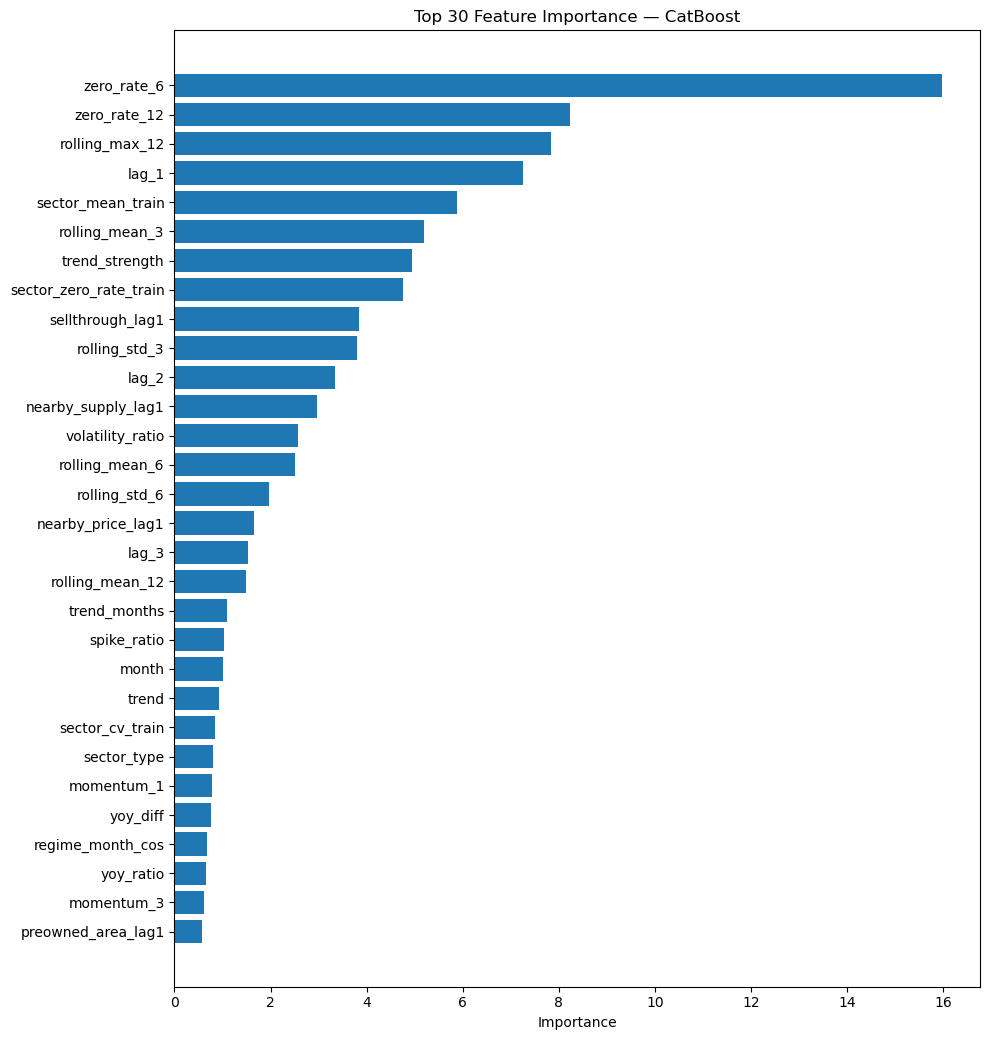

In [31]:
# Lấy feature names từ X_train
sector_stats   = compute_sector_stats(train_df, TARGET_LOG)
sector_profile = build_sector_profile(train_df)
df_featured    = create_training_features(
    train_df, target_col=TARGET_LOG,
    sector_stats=sector_stats,
    sector_profile=sector_profile,
    keep_nan=False
)
feats = get_valid_features(df_featured)

fi_df = plot_feature_importance(final_model, feats, top_n=30, model_name="CatBoost")